<a href="https://colab.research.google.com/github/erin-carroll/chess-isofit/blob/main/tutorials/explore_the_mosaic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The mosaicked reflectance data are stored as netcdf files in 1000x1000 m chunks, on the same spatial grid as the NEON lidar-derived data products. Each netcdf tile has two main data variables stored as arrays: (1) surface reflectance and (2) associated uncertainty estimates for each of the 426 bands measured by the NEON Imaging Spectrometer. The wavelength centers and full width at half maximum (fwhm) for each band in nanometers (nm) are also stored as metadata. All of the data is in EPSG 32613.

The file naming convention is:

`{domain}_{year}_rfl_{x coordinate of the lower left corner}_{y coordinate of the lower left corner}.nc`

This tutorial goes through opening a single .nc tile, exploring the data inside, and visualizing the data interactively alongside ancillary spatial data.

In [6]:
import xarray as xr
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# to call files directly from google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# choose an area you want to work with and identify the file path to the relevant .nc file.
# this tile covers the Trail 403 site from the CRBU domain.
fp_rfl = '/content/drive/MyDrive/CHESS/Data/CHESS_workshop_data/spectrometer_tutorial/CRBU_2025_mosaic_rfl_325000_4316000.nc' # convert to s3 filepath and loading once up

# if you have polygons you want to visualize alongside the raster, identify the filepath to those too
fp_poly = '/content/drive/MyDrive/CHESS/Data/CHESS_workshop_data/spectrometer_tutorial/CRBU2018_AOP_Crowns.geojson'

In [ ]:
# First, open the .nc file and take a look at what is inside.
# Opening .nc files with xarray.open_dataset() does lazy loading, meaning the data stays on the disk and is not loaded into memory until called

ds = xr.open_dataset(fp_rfl)
ds

<xarray.Dataset> Size: 3GB
Dimensions:                  (wavelength: 426, northing: 1000, easting: 1000)
Coordinates:
  * wavelength               (wavelength) float64 3kB 383.9 388.9 ... 2.512e+03
  * northing                 (northing) float64 8kB 4.317e+06 ... 4.316e+06
  * easting                  (easting) float64 8kB 3.25e+05 ... 3.26e+05
Data variables:
    reflectance              (wavelength, northing, easting) float32 2GB ...
    fwhm                     (wavelength) float64 3kB ...
    transverse_mercator      int64 8B ...
    reflectance_uncertainty  (wavelength, northing, easting) float32 2GB ...
Attributes:
    Conventions:   CF-1.6
    date_created:  2026-03-06T23:24:40Z
    summary:       This dataset represents land surface reflectance estimates...
    instrument:    NEON Imaging Spectrometer
    platform:      NEON Airborne Observation Platform
    citation:      Carroll E ; Goulden T ; Chadwick K D ; Ade C ; Eckert R ; ...

In [ ]:
# the center wavelength and FWHM values can be called like
wvl = ds['wavelength']
fwhm = ds['fwhm']
wvl.shape, fwhm.shape

((426,), (426,))

In [ ]:
# the reflectance and uncertainty data can similarly be called like
rfl = ds['reflectance']
unc = ds['reflectance_uncertainty']
rfl.shape, unc.shape

# This returns an xarray DataArray, which is still a lazy loading. The DataArray stores the coordinates and dimensions and is backed by the NetCDF file on disk. The data is not loaded into memory until you call .values

((426, 1000, 1000), (426, 1000, 1000))

To convert to a numpy array, which loads ALL of data in the array into memory, you would run
    `rfl = ds['reflectance'].values`

Avoid loading the entire cube into memory this way unless you really need to. Instead, we might load subsets like:
* the full spectrum of an individual pixel
* a few bands for the entire tile (e.g. rgb, or a subset needed to calculate a spectral index like NDVI)

(426,) (426,)


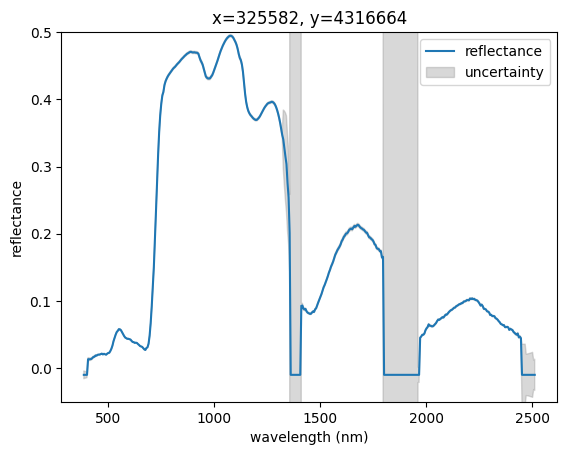

In [ ]:
# say we're interested in the entire reflectance spectrum at the pixel nearest the coordinate:
x, y = (325582, 4316664)

# we could load the reflectance and uncertainty data at that pixel
px_rfl = rfl.sel(easting=x, northing=y, method='nearest').values
px_unc = unc.sel(easting=x, northing=y, method='nearest').values
print(px_rfl.shape, px_unc.shape)

# and then visualize that pixel spectrum
fig = plt.figure()
plt.plot(wvl, px_rfl, label='reflectance')
plt.fill_between(wvl, px_rfl - px_unc, px_rfl + px_unc, color='gray', alpha=0.3, label='uncertainty')
plt.ylim(-0.05,0.5)
plt.xlabel('wavelength (nm)')
plt.ylabel('reflectance')
plt.title(f'x={x}, y={y}')
plt.legend()
plt.show()

# outside of major atmospheric absorption features, the uncertainty values are quite small

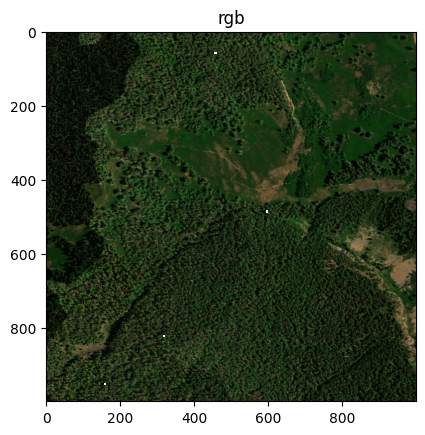

In [ ]:
# We could also generate an rgb visualization of the image

rgb = rfl.isel(wavelength=[58, 34, 19]).values
rgb = np.moveaxis(rgb, 0, 2) # matplotlib wants the bands as the last axis, not the first
rgb = rgb / np.nanmax(rgb) # brighten the image

fig = plt.figure()
plt.imshow(rgb)
plt.title('rgb')
plt.show()

You'll notice a clear brightness boundary on the left side of the image above. This is a boundary between individual flightlines that were stitched together to form the mosaic. Because different flightlines were collected with different relative geometries between the sensor and the sun, they differ in brightness as a function of the sensor seeing more or less shadow on non-lambertian surfaces. These reflectance data are NOT brdf corrected! So it can be useful to brightness-normalize your data before training and deploying a model. You could alternatively take the step of applying your own brdf correction.

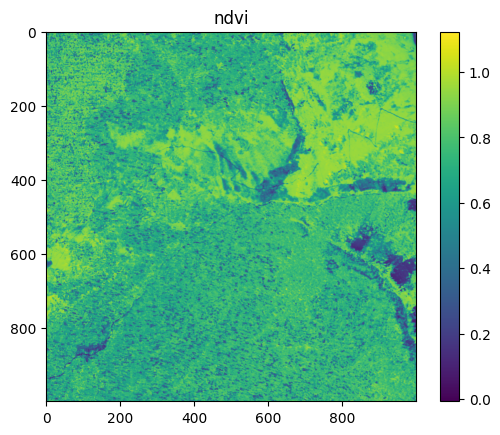

In [ ]:
# To look at NDVI, we would do something like

# select red and nir bands using band indices
red = rfl.isel(wavelength=58).values
nir = rfl.isel(wavelength=89).values

# or wavelengths
red = rfl.sel(wavelength=669, method='nearest').values
nir = rfl.sel(wavelength=830, method='nearest').values

ndvi = np.true_divide((nir-red),(nir+red))

fig = plt.figure()
plt.imshow(ndvi)
plt.title('ndvi')
plt.colorbar()
plt.show()

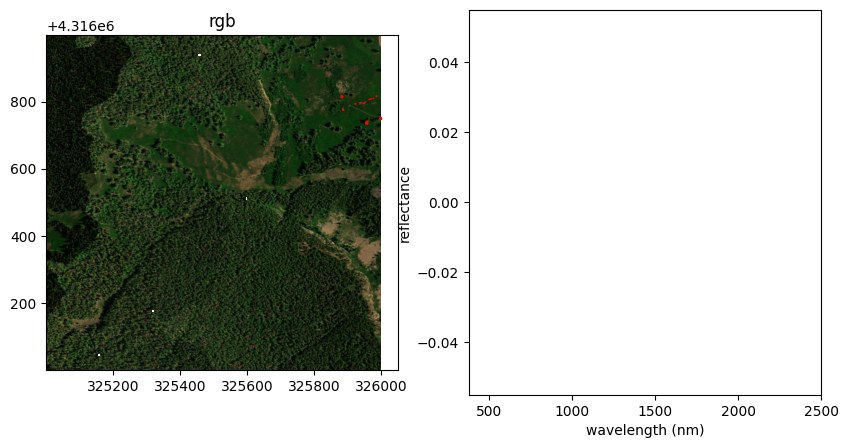

In [ ]:
# We could also
# (1) overlay ancillary spatial data on the raster, and
# (2) put together an interactive plotting feature that shows the spectrum of whatever pixel we click on
# In the resulting plot, use the interactive plotting features to zoom in on the red polygons. Click around to visualize different spectra.

# # interactive plotting is currently broken in colab but this will work in other notebook environments
# %matplotlib notebook

# prepare spatial data
extent = [
    float(rfl.easting.min()),
    float(rfl.easting.max()),
    float(rfl.northing.min()),
    float(rfl.northing.max()),
]
gdf = gpd.read_file(fp_poly)
gdf = gdf.to_crs(ds['transverse_mercator'].attrs['epsg_code']) # make sure this is in the same crs as the .nc file
gdf = gdf.cx[extent[0]:extent[1], extent[2]:extent[3]] # clip to the extent of the tile

# plot
fig, axs = plt.subplots(ncols=2, figsize=(10,5))

axs[0].imshow(rgb, extent=extent, origin='upper')
gdf.plot(ax=axs[0], facecolor='none', edgecolor='red', linewidth=1)

(px_rfl,) = axs[1].plot([], [])
px_unc = None

def on_click(event):
    global px_unc
    col_ = int(np.round(event.xdata))
    row_ = int(np.round(event.ydata))
    print(col_, row_)

    px_rfl_ = rfl.sel(easting=col_, northing=row_, method='nearest').values
    px_unc_ = unc.sel(easting=col_, northing=row_, method='nearest').values
    px_rfl.set_data(wvl, px_rfl_)

    if px_unc is not None:
        px_unc.remove()
    px_unc = axs[1].fill_between(wvl, px_rfl_ - px_unc_, px_rfl_ + px_unc_, color='gray', alpha=0.3)

    axs[1].relim()
    axs[1].autoscale_view()
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect('button_press_event', on_click)

# axs[1].set_ylim(0,1)
axs[1].set_xlim(380,2500)
axs[0].set_title('rgb')
axs[1].set_xlabel('wavelength (nm)')
axs[1].set_ylabel('reflectance')
plt.show()